In [1]:
import pandas as pd
import numpy as np
np.random.seed(42)
dates = pd.date_range(start='2025-01-01', end='2025-12-31')
zones = [1, 2, 3, 4, 5]
data = []
for zone in zones:
    for date in dates:
        temp = np.random.normal(30, 5)  # Avg temp ~30°C
        humidity = np.random.uniform(40, 90)
        event = np.random.choice([0, 1], p=[0.85, 0.15])
        consumption = (
            50 +
            temp * 2 +
            humidity * 0.5 +
            event * 20 +
            np.random.normal(0, 5)
        )
        data.append([date, zone, temp, humidity, event, consumption])
df = pd.DataFrame(data, columns=[
    'Date', 'ZoneID', 'AvgTemperature', 'Humidity', 'SpecialEvent', 'EnergyConsumption'
])
df['Month'] = df['Date'].dt.month
df.head()

,Date,ZoneID,AvgTemperature,Humidity,SpecialEvent,EnergyConsumption,Month
0,2025-01-01,1,32.483571,76.599697,0,152.575669,1
1,2025-01-02,1,28.829233,42.904181,1,147.939872,1
2,2025-01-03,1,37.896064,41.029225,1,170.143914,1
3,2025-01-04,1,27.652628,49.091248,0,132.563681,1
4,2025-01-05,1,31.209811,61.597251,0,133.651847,1


In [2]:
print(df.isnull().sum())
df = df.dropna()
df['ZoneID'] = df['ZoneID'].astype(int)
df['SpecialEvent'] = df['SpecialEvent'].astype(int)

Date                 0
ZoneID               0
AvgTemperature       0
Humidity             0
SpecialEvent         0
EnergyConsumption    0
Month                0
dtype: int64


In [3]:
monthly_avg = df.groupby('Month')['EnergyConsumption'].mean()
print(monthly_avg)

Month
1     143.941943
2     146.624567
3     145.412642
4     147.294751
5     144.955478
6     144.024934
7     144.592264
8     145.303654
9     145.889444
10    145.552271
11    147.007386
12    144.669526
Name: EnergyConsumption, dtype: float64


In [22]:
correlation = df[['AvgTemperature', 'Humidity', 'SpecialEvent', 'EnergyConsumption']].corr()

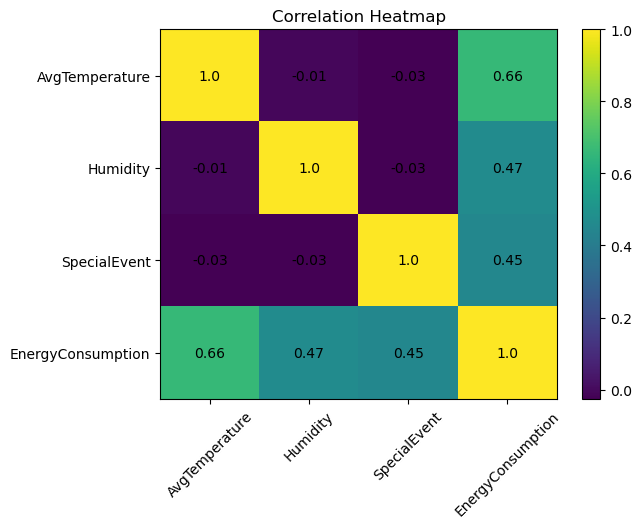

In [23]:
import matplotlib.pyplot as plt

plt.imshow(correlation, aspect='auto')
plt.colorbar()

plt.xticks(range(len(correlation.columns)), correlation.columns, rotation=45)
plt.yticks(range(len(correlation.columns)), correlation.columns)

# Add values inside cells
for i in range(len(correlation.columns)):
    for j in range(len(correlation.columns)):
        plt.text(j, i, round(correlation.iloc[i, j], 2),
                 ha='center', va='center')

plt.title("Correlation Heatmap")
plt.show()

In [24]:
monthly_avg = df.groupby('Month')['EnergyConsumption'].mean()
print(monthly_avg)

Month
1     143.941943
2     146.624567
3     145.412642
4     147.294751
5     144.955478
6     144.024934
7     144.592264
8     145.303654
9     145.889444
10    145.552271
11    147.007386
12    144.669526
Name: EnergyConsumption, dtype: float64


In [25]:
zone_avg = df.groupby('ZoneID')['EnergyConsumption'].mean()
print(zone_avg)

ZoneID
1    146.034848
2    145.122830
3    145.364913
4    146.193427
5    144.396919
Name: EnergyConsumption, dtype: float64


In [26]:
correlation = df[['AvgTemperature','Humidity','SpecialEvent','EnergyConsumption']].corr()
print(correlation)

                   AvgTemperature  Humidity  SpecialEvent  EnergyConsumption
AvgTemperature           1.000000 -0.006381     -0.026335           0.660243
Humidity                -0.006381  1.000000     -0.026044           0.467892
SpecialEvent            -0.026335 -0.026044      1.000000           0.448562
EnergyConsumption        0.660243  0.467892      0.448562           1.000000


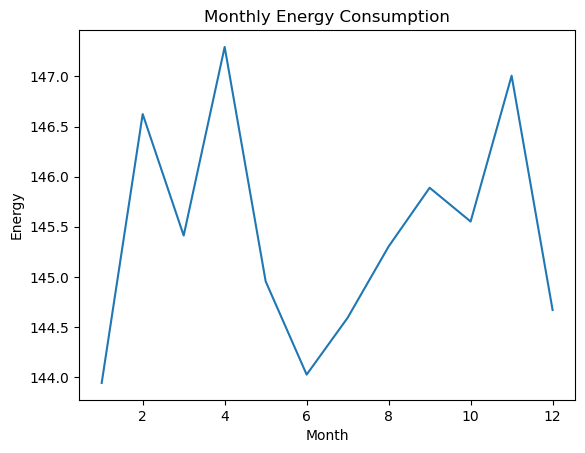

In [27]:
import matplotlib.pyplot as plt

monthly_avg.plot()
plt.title("Monthly Energy Consumption")
plt.xlabel("Month")
plt.ylabel("Energy")
plt.show()

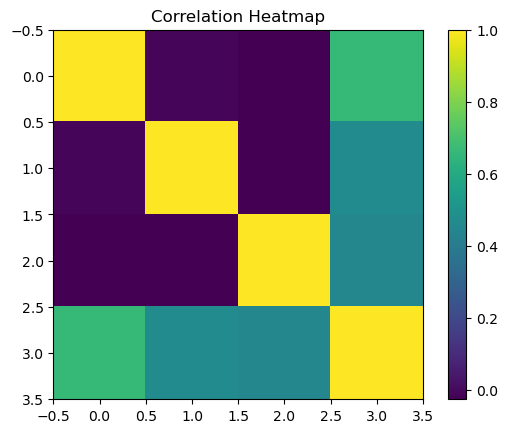

In [28]:
plt.imshow(correlation)
plt.colorbar()
plt.title("Correlation Heatmap")
plt.show()

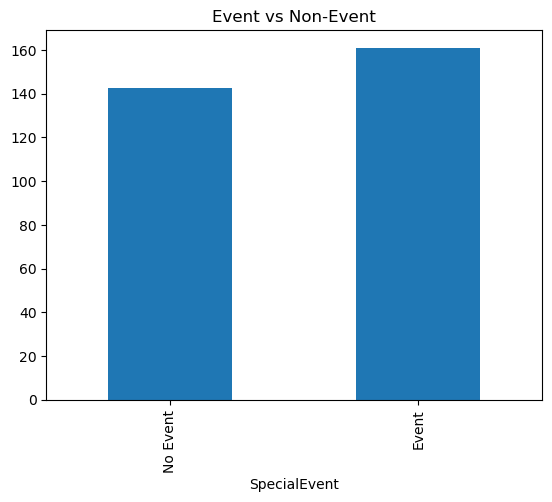

In [29]:
event_avg = df.groupby('SpecialEvent')['EnergyConsumption'].mean()

event_avg.plot(kind='bar')
plt.xticks([0,1], ['No Event', 'Event'])
plt.title("Event vs Non-Event")
plt.show()

In [30]:
from sklearn.model_selection import train_test_split

X = df[['ZoneID','AvgTemperature','Humidity','SpecialEvent']]
y = df['EnergyConsumption']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

In [31]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [32]:
from sklearn.metrics import mean_absolute_error

pred = model.predict(X_test)
print("MAE:", mean_absolute_error(y_test, pred))

MAE: 4.2589709208459645


In [33]:
import numpy as np

zone = int(input("Zone ID: "))
temp = float(input("Temperature: "))
humidity = float(input("Humidity: "))
event = int(input("Event (0/1): "))

prediction = model.predict([[zone, temp, humidity, event]])

print("Predicted Energy:", prediction[0])

Zone ID:  4
Temperature:  43
Humidity:  34
Event (0/1):  1


/lib/python3.13/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


Predicted Energy: 172.5294356695382
